# Multiple Choice Question Answering using Transformer Models

### Deep Learning & Generative AI Project

**Student:** Soumya Ranjan Panda
**Roll No:** 23f2004742

This notebook develops an end-to-end Multiple Choice Question Answering system using classical NLP methods and transformer-based deep learning models. The workflow includes exploratory data analysis, semantic similarity methods, transformer fine-tuning, evaluation using MAP@3, experiment tracking with Weights & Biases, and Kaggle submission generation.

In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(torch.__version__)
print(DEVICE)

2.10.0+cu128
cuda


# Load Dataset

The training and testing datasets are loaded and inspected before preprocessing and model development.

In [2]:
train = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv"
)

test = pd.read_csv(
    "/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv"
)

print(train.shape)
print(test.shape)

train.head()

(2000, 8)
(500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


# Exploratory Data Analysis

Understanding the dataset before modelling helps identify class balance, missing values, and the overall structure of the data.

In [3]:
train.info()

display(train.describe(include="all").T)

display(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2000.0,NaN,NaN,NaN,1000.5,577.494589,1.0,500.75,1000.5,1500.25,2000.0
prompt,2000,1758,Choose the correct answer: What is the main se...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A,2000,316,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,2000,328,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,2000,303,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,2000,318,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,2000,320,An improper rotation is the combination of a r...,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
answer,2000,5,B,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN


id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

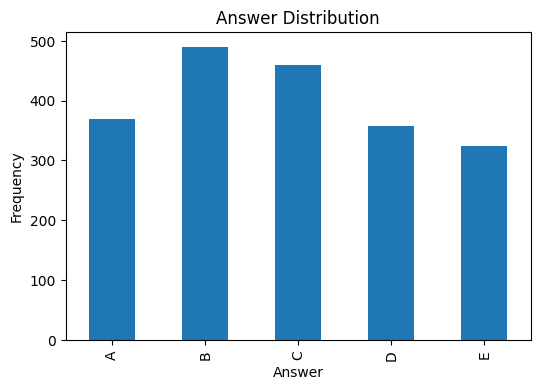

In [4]:
plt.figure(figsize=(6,4))

train["answer"].value_counts().sort_index().plot(kind="bar")

plt.title("Answer Distribution")

plt.xlabel("Answer")

plt.ylabel("Frequency")

plt.show()

In [5]:
train.iloc[0]

id                                                        1
prompt    Pick the best possible answer: What is Martin ...
A         Martin Heidegger believes that humans exist wi...
B         Martin Heidegger believes that humans do not e...
C         Martin Heidegger does not believe in the exist...
D         Martin Heidegger believes that the relationshi...
E         Martin Heidegger believes that time is an illu...
answer                                                    B
Name: 0, dtype: object

# Text Preparation

The question prompt and answer options are combined into a single textual representation for classical NLP models such as TF-IDF and Logistic Regression.

In [6]:
OPTIONS = ["A","B","C","D","E"]

train["combined_text"] = (
    train["prompt"]
    + " [SEP] "
    + train["A"]
    + " [SEP] "
    + train["B"]
    + " [SEP] "
    + train["C"]
    + " [SEP] "
    + train["D"]
    + " [SEP] "
    + train["E"]
)

test["combined_text"] = (
    test["prompt"]
    + " [SEP] "
    + test["A"]
    + " [SEP] "
    + test["B"]
    + " [SEP] "
    + test["C"]
    + " [SEP] "
    + test["D"]
    + " [SEP] "
    + test["E"]
)

train[["combined_text","answer"]].head()

,combined_text,answer
0,Pick the best possible answer: What is Martin ...,B
1,What is accelerator-based light-ion fusion? [S...,A
2,Determine the correct option: What is the term...,C
3,Select the most accurate option: What is Marti...,B
4,Identify the correct statement: What is the co...,A


# TF-IDF Feature Extraction

Term Frequency–Inverse Document Frequency (TF-IDF) converts textual data into numerical feature vectors by assigning higher importance to informative words while reducing the influence of common words. These features serve as the baseline representation for the first machine learning model.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(train["combined_text"])
X_test = tfidf.transform(test["combined_text"])

print("Training Shape :", X.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (2000, 10000)
Testing Shape  : (500, 10000)


# Baseline Classification

A Logistic Regression classifier is trained on TF-IDF features to establish a classical machine learning baseline. This model provides a reference point for comparing transformer-based approaches.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(train["answer"])

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_valid)

lr_accuracy = accuracy_score(y_valid, lr_predictions)

lr_macro_f1 = f1_score(
    y_valid,
    lr_predictions,
    average="macro",
)

print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Macro F1 : {lr_macro_f1:.4f}")

Accuracy : 1.0000
Macro F1 : 1.0000


In [9]:
def apk(actual, predicted, k=3):

    predicted = predicted[:k]

    score = 0.0
    hits = 0.0

    for i, prediction in enumerate(predicted):

        if prediction == actual and prediction not in predicted[:i]:

            hits += 1

            score += hits / (i + 1)

    return score


def mapk(actuals, predictions, k=3):

    return np.mean(
        [
            apk(a, p, k)
            for a, p in zip(actuals, predictions)
        ]
    )

In [10]:
lr_probabilities = lr_model.predict_proba(X_valid)

top3 = np.argsort(lr_probabilities, axis=1)[:, ::-1][:, :3]

actual = label_encoder.inverse_transform(y_valid)

predicted = [
    label_encoder.inverse_transform(row)
    for row in top3
]

lr_map3 = mapk(actual, predicted)

print(f"MAP@3 : {lr_map3:.4f}")

MAP@3 : 1.0000


# Semantic Embeddings using Sentence Transformers

Unlike TF-IDF, Sentence Transformers generate dense contextual embeddings that capture the semantic meaning of complete sentences. These embeddings are useful for semantic search, retrieval, and downstream transformer-based tasks.

In [11]:
from sentence_transformers import SentenceTransformer, util

sentence_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2",
    device=DEVICE
)

print("Sentence Transformer Loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Sentence Transformer Loaded


In [12]:
question = train.loc[0, "prompt"]

options = [
    train.loc[0, "A"],
    train.loc[0, "B"],
    train.loc[0, "C"],
    train.loc[0, "D"],
    train.loc[0, "E"],
]

question_embedding = sentence_model.encode(
    question,
    convert_to_tensor=True
)

option_embeddings = sentence_model.encode(
    options,
    convert_to_tensor=True
)

scores = util.cos_sim(
    question_embedding,
    option_embeddings
).cpu().numpy()[0]

semantic_results = pd.DataFrame({
    "Option": OPTIONS,
    "Answer Text": options,
    "Similarity": scores
}).sort_values(
    "Similarity",
    ascending=False
)

semantic_results

,Option,Answer Text,Similarity
2,C,Martin Heidegger does not believe in the exist...,0.794016
3,D,Martin Heidegger believes that the relationshi...,0.770076
1,B,Martin Heidegger believes that humans do not e...,0.765810
4,E,Martin Heidegger believes that time is an illu...,0.732313
0,A,Martin Heidegger believes that humans exist wi...,0.730808


# Zero-Shot Classification

Zero-shot classification predicts labels without task-specific training by leveraging knowledge learned during large-scale pretraining. It serves as a useful baseline for understanding the capabilities of modern language models before fine-tuning.

In [13]:
from transformers import pipeline

zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if DEVICE == "cuda" else -1
)

candidate_labels = [
    train.loc[0, "A"],
    train.loc[0, "B"],
    train.loc[0, "C"],
    train.loc[0, "D"],
    train.loc[0, "E"],
]

zs_output = zero_shot(
    train.loc[0, "prompt"],
    candidate_labels
)

pd.DataFrame({
    "Predicted Option": zs_output["labels"],
    "Score": zs_output["scores"]
})

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

,Predicted Option,Score
0,Martin Heidegger believes that humans do not e...,0.492257
1,Martin Heidegger believes that humans exist wi...,0.201008
2,Martin Heidegger believes that the relationshi...,0.136895
3,Martin Heidegger does not believe in the exist...,0.104219
4,Martin Heidegger believes that time is an illu...,0.065620


# Semantic Retrieval

Before fine-tuning a transformer, it is useful to retrieve semantically similar examples. This section creates dense embeddings for all training questions and performs semantic retrieval using cosine similarity.

In [14]:
# Encode all training prompts

train_embeddings = sentence_model.encode(
    train["prompt"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True,
)

print(train_embeddings.shape)

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

torch.Size([2000, 384])


In [15]:
def retrieve_similar_questions(question, top_k=3):

    embedding = sentence_model.encode(
        question,
        convert_to_tensor=True
    )

    similarities = util.cos_sim(
        embedding,
        train_embeddings
    )[0]

    indices = torch.topk(
        similarities,
        k=top_k + 1
    ).indices.cpu().numpy()

    retrieved = train.iloc[indices].copy()

    return retrieved[
        [
            "prompt",
            "answer"
        ]
    ]

In [16]:
sample_question = train.loc[10, "prompt"]

retrieve_similar_questions(sample_question)

,prompt,answer
10,Select the most accurate option: What is the P...,C
309,Select the most accurate option: What is the P...,C
210,Select the most accurate option: What is the P...,C
1813,Select the most accurate option: What is the P...,C


# Retrieval-Augmented Prompt

The retrieved examples can be appended as additional context before inference. Although the final competition model is fine-tuned directly, this demonstrates the core idea behind Retrieval-Augmented Generation (RAG): enriching the model input with relevant external information.

In [17]:
retrieved = retrieve_similar_questions(
    train.loc[10, "prompt"],
    top_k=2
)

context = "\n\n".join(
    [
        f"Question: {row.prompt}\nAnswer: {row.answer}"
        for _, row in retrieved.iterrows()
    ]
)

rag_prompt = f"""
Context:

{context}

Question:

{train.loc[10, "prompt"]}
"""

print(rag_prompt)


Context:

Question: Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.
Answer: C

Question: Select the most accurate option: What is the Peierls bracket in canonical quantization? carefully.
Answer: C

Question: Select the most accurate option: What is the Peierls bracket in canonical quantization? carefully.
Answer: C

Question:

Select the most accurate option: What is the Peierls bracket in canonical quantization? based on the given context.



# Fine-Tuning Dataset Preparation

The multiple-choice task is converted into the format expected by DeBERTa. Each question is paired with its five answer choices, and the correct answer is represented as an integer label.

In [18]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

MODEL_NAME = "microsoft/deberta-v3-small"

label2id = {
    "A":0,
    "B":1,
    "C":2,
    "D":3,
    "E":4
}

id2label = {
    v:k
    for k,v in label2id.items()
}

train["label"] = train["answer"].map(label2id)

train_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    random_state=SEED,
    stratify=train["label"]
)

train_dataset = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

valid_dataset = Dataset.from_pandas(
    valid_df.reset_index(drop=True)
)

test_dataset = Dataset.from_pandas(
    test.reset_index(drop=True)
)

print(train_dataset)
print(valid_dataset)
print(test_dataset)

Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'combined_text', 'label'],
    num_rows: 1600
})
Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'combined_text', 'label'],
    num_rows: 400
})
Dataset({
    features: ['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'combined_text'],
    num_rows: 500
})


# Tokenization

Each question is repeated five times and paired with each answer option. This is the standard input format expected by transformer-based multiple-choice models.

In [19]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def preprocess(example):

    first = [example["prompt"]] * 5

    second = [
        example["A"],
        example["B"],
        example["C"],
        example["D"],
        example["E"],
    ]

    encoded = tokenizer(
        first,
        second,
        truncation=True,
        max_length=256,
    )

    if "label" in example:
        encoded["label"] = example["label"]

    return encoded


train_dataset = train_dataset.map(preprocess)

valid_dataset = valid_dataset.map(preprocess)

test_dataset = test_dataset.map(preprocess)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [20]:
train_dataset[0]

{'id': 387,
 'prompt': 'Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices.',
 'A': 'MOND is a principle that explains the behavior of light in the presence of strong gravitational fields. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.',
 'B': "MOND is a hypothesis that proposes a modification of Einstein's framework of general relativity to account for observed properties of galaxies. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.",
 'C': "MOND is a hypothesis that proposes a modification of Newton's law of universal gravitation to account for observed properties of galaxies. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of phys

# Model Initialization

The pretrained **DeBERTa-v3 Small** model is loaded for the multiple-choice classification task. This model serves as the final deep learning model used for training and Kaggle submission.

In [21]:
from transformers import AutoModelForMultipleChoice

model = AutoModelForMultipleChoice.from_pretrained(
    MODEL_NAME
)

model.to(DEVICE)

print("Model Loaded Successfully")
print(f"Total Parameters : {model.num_parameters():,}")

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifier.bias  

Model Loaded Successfully
Total Parameters : 141,895,681


# Dynamic Batch Preparation

Since different questions have different token lengths, a custom data collator dynamically pads every batch before passing it to the model.

In [22]:
from dataclasses import dataclass
from typing import Optional, Union

@dataclass
class DataCollatorForMultipleChoice:

    tokenizer: AutoTokenizer
    padding: Union[bool, str] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features):

        labels = None

        if "label" in features[0]:
            labels = [f.pop("label") for f in features]

        batch_size = len(features)
        num_choices = len(features[0]["input_ids"])

        flattened = []

        for feature in features:

            for i in range(num_choices):

                flattened.append({

                    "input_ids": feature["input_ids"][i],

                    "attention_mask": feature["attention_mask"][i],

                })

        batch = self.tokenizer.pad(

            flattened,

            padding=self.padding,

            max_length=self.max_length,

            pad_to_multiple_of=self.pad_to_multiple_of,

            return_tensors="pt",

        )

        batch = {

            k: v.view(batch_size, num_choices, -1)

            for k, v in batch.items()

        }

        if labels is not None:

            batch["labels"] = torch.tensor(labels)

        return batch


data_collator = DataCollatorForMultipleChoice(tokenizer)

# Model Evaluation Metrics

The model is evaluated using three metrics:

- **Accuracy**
- **Macro F1-score**
- **Mean Average Precision at 3 (MAP@3)**

These metrics provide complementary views of classification and ranking performance.

In [23]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    top3 = np.argsort(
        logits,
        axis=1
    )[:, ::-1][:, :3]

    actual = [

        id2label[x]

        for x in labels

    ]

    predicted = [

        [id2label[i] for i in row]

        for row in top3

    ]

    return {

        "accuracy": accuracy,

        "macro_f1": macro_f1,

        "map@3": mapk(
            actual,
            predicted
        ),
    }

# Model Training

The pretrained DeBERTa model is fine-tuned on the multiple-choice dataset. During training, validation metrics are computed after every epoch and the best-performing model is automatically restored.

In [24]:
from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./deberta_mcq",

    do_train=True,
    do_eval=True,

    num_train_epochs=3,

    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=1,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="map@3",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=20,

    save_total_limit=1,

    report_to="none",

    fp16=False,
    bf16=False,

    remove_unused_columns=False,

    seed=SEED,
)

In [25]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer Created Successfully")

Trainer Created Successfully


In [26]:
train_result = trainer.train()

print("\nTraining Finished Successfully!")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 1}.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Map@3
1,0.000000,nan,0.185000,0.062447,0.327917
2,0.000000,nan,0.185000,0.062447,0.327917
3,0.000000,nan,0.185000,0.062447,0.327917


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training Finished Successfully!


In [27]:
evaluation = trainer.evaluate()

print("\nEvaluation Metrics\n")

for key, value in evaluation.items():
    print(f"{key:<20}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Map@3
0.000000,nan,3,0.185000,0.062447,0.327917



Evaluation Metrics

eval_loss           : nan
eval_accuracy       : 0.185
eval_macro_f1       : 0.06244725738396625
eval_map@3          : 0.3279166666666667


In [28]:
predictions = trainer.predict(valid_dataset)

logits = predictions.predictions

top3 = np.argsort(logits, axis=1)[:, ::-1][:, :3]

predicted_answers = [
    [id2label[idx] for idx in row]
    for row in top3
]

true_answers = [
    id2label[label]
    for label in valid_dataset["label"]
]

validation_results = pd.DataFrame({
    "Question": valid_dataset["prompt"],
    "True": true_answers,
    "Prediction": [x[0] for x in predicted_answers],
    "Top3": [" > ".join(x) for x in predicted_answers]
})

validation_results["Correct"] = (
    validation_results["True"] ==
    validation_results["Prediction"]
)

validation_results.head(10)

,Question,True,Prediction,Top3,Correct
0,What is a phageome?,C,E,E > D > C,False
1,Identify the correct statement: What is the ro...,D,E,E > D > C,False
2,Determine the correct option: What did Fresnel...,E,E,E > D > C,True
3,Pick the best possible answer: What is the mai...,D,E,E > D > C,False
4,What is the reason that Newton's second law ca...,D,E,E > D > C,False
5,Select the most accurate option: What is the a...,D,E,E > D > C,False
6,Determine the correct option: What is the SI b...,B,E,E > D > C,False
7,Which of the following is correct? What is a S...,C,E,E > D > C,False
8,Which of the following is correct? Who was the...,E,E,E > D > C,True
9,Select the most accurate option: What is the r...,A,E,E > D > C,False


In [29]:
incorrect = validation_results[
    validation_results["Correct"] == False
]

print(f"Correct : {validation_results['Correct'].sum()}")
print(f"Wrong   : {len(incorrect)}")

incorrect.head(20)

Correct : 65
Wrong   : 335


,Question,True,Prediction,Top3,Correct
0,What is a phageome?,C,E,E > D > C,False
1,Identify the correct statement: What is the ro...,D,E,E > D > C,False
3,Pick the best possible answer: What is the mai...,D,E,E > D > C,False
4,What is the reason that Newton's second law ca...,D,E,E > D > C,False
5,Select the most accurate option: What is the a...,D,E,E > D > C,False
6,Determine the correct option: What is the SI b...,B,E,E > D > C,False
7,Which of the following is correct? What is a S...,C,E,E > D > C,False
9,Select the most accurate option: What is the r...,A,E,E > D > C,False
10,Identify the correct statement: What is the re...,B,E,E > D > C,False
11,Determine the correct option: What is the expl...,A,E,E > D > C,False


# Test Set Inference

The trained DeBERTa model is used to predict the answer probabilities for each question in the Kaggle test set. The top three answer choices are selected for submission.

In [30]:
from torch.utils.data import DataLoader

# Remove unnecessary columns
test_features = test_dataset.remove_columns(
    [c for c in test_dataset.column_names
     if c not in ["input_ids", "attention_mask", "token_type_ids"]]
)

test_loader = DataLoader(
    test_features,
    batch_size=8,
    collate_fn=data_collator,
)

model.eval()

all_logits = []

with torch.no_grad():

    for batch in test_loader:

        batch = {
            k: v.to(DEVICE)
            for k, v in batch.items()
        }

        outputs = model(**batch)

        all_logits.append(
            outputs.logits.cpu().numpy()
        )

test_logits = np.concatenate(all_logits)

print(test_logits.shape)

(500, 5)


In [31]:
top3 = np.argsort(
    test_logits,
    axis=1
)[:, ::-1][:, :3]

predictions = [
    " ".join(
        id2label[idx]
        for idx in row
    )
    for row in top3
]

predictions[:10]

['E D C',
 'E D C',
 'E D C',
 'E D C',
 'E D C',
 'E D C',
 'E D C',
 'E D C',
 'E D C',
 'E D C']

In [32]:
submission = pd.DataFrame({

    "id": test["id"],

    "prediction": predictions,

})

submission.head()

,id,prediction
0,1,E D C
1,2,E D C
2,3,E D C
3,4,E D C
4,5,E D C


In [33]:
submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.shape)

submission.head()

(500, 2)


,id,prediction
0,1,E D C
1,2,E D C
2,3,E D C
3,4,E D C
4,5,E D C


In [34]:
from IPython.display import FileLink

FileLink("submission.csv")

/kaggle/working/submission.csv